# Banking Fraud Detection


## 1. Setup & Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, roc_curve, average_precision_score,PrecisionRecallDisplay)
from sklearn.model_selection import cross_val_score
!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

## 2. Data Loading & Initial Exploration

The dataset contains credit card transactions labelled as fraudulent (`is_fraud=1`) or legitimate (`is_fraud=0`).  

In [62]:
df_train = pd.read_csv('fraudTrain.csv',index_col=0)
df_test  = pd.read_csv('fraudTest.csv',index_col=0)
print(f'Training set: {df_train.shape[0]} rows× {df_train.shape[1]} columns')
print(f'Test set: {df_test.shape[0]} rows× {df_test.shape[1]} columns')
df_train.head(3)

Training set: 1296675 rows× 22 columns
Test set: 555719 rows× 22 columns


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0


In [4]:
#data types and missing value
print('Data types\n')
print(df_train.dtypes)
print('\n Missing values')
print(df_train.isnull().sum())

Data types

trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

 Missing values
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street         

Legitimate transactions: 1289169
Fraudulent transactions: 7506
Fraud rate: 0.58%


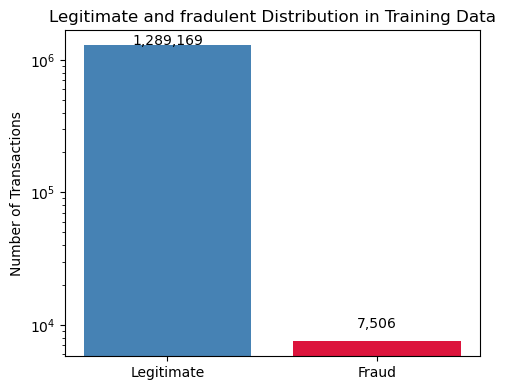

In [63]:
fraud_counts=df_train['is_fraud'].value_counts()
fraud_rate= fraud_counts[1]/len(df_train) * 100

print(f'Legitimate transactions: {fraud_counts[0]}')
print(f'Fraudulent transactions: {fraud_counts[1]}')
print(f'Fraud rate: {fraud_rate:.2f}%')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Legitimate', 'Fraud'], fraud_counts.values, color=['steelblue', 'crimson'])
ax.set_title('Legitimate and fradulent Distribution in Training Data')
ax.set_yscale('log')
ax.set_ylabel('Number of Transactions')
for i, v in enumerate(fraud_counts.values):
   ax.text(i, v + 2000, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('class_balance.png', dpi=150)
plt.show()

## 3. Data Cleaning & Pre-processing

In [6]:
def preprocess(df):
    df = df.copy()

    # date and time parsing 
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dob'] = pd.to_datetime(df['dob'])

    # Getting time values from the timestamop
    df['hour']= df['trans_date_trans_time'].dt.hour       
    df['day_of_week']= df['trans_date_trans_time'].dt.dayofweek  
    df['month']= df['trans_date_trans_time'].dt.month      
    # finfing age 
    df['age'] = ((df['trans_date_trans_time'] - df['dob']).dt.days / 365.25).astype(int)

    # Distance between cardholder and merchant because usually in real life large geographic distance is related with fraud
    R = 6371 
    lat1 = np.radians(df['lat'])
    lat2 = np.radians(df['merch_lat'])
    dlat = lat2 - lat1
    dlon = np.radians(df['merch_long'] - df['long'])
    a    = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    df['distance_km'] = 2 * R * np.arcsin(np.sqrt(a))

    # Finding gender 
    df['gender_enc']=(df['gender']=='M').astype(int)

    # Finding category
    le = LabelEncoder()
    df['category_enc'] = le.fit_transform(df['category'])

    #dropping unnecessary columns
    drop_cols = ['trans_date_trans_time','cc_num','merchant','first','last','street','city','state','zip','dob','trans_num','gender',
                 'category','unix_time']
    df.drop(columns=drop_cols, inplace=True)

    return df


df_train_clean = preprocess(df_train)
df_test_clean  = preprocess(df_test)

print('Cleaned training shape:', df_train_clean.shape)

Cleaned training shape: (1296675, 15)


## 4 Data Analysis with visualization


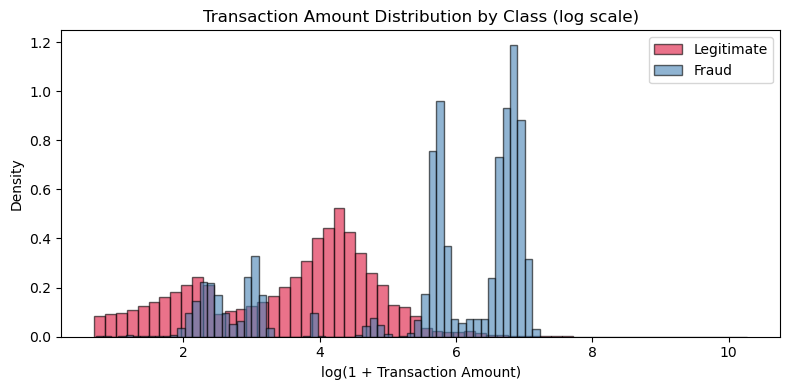

In [10]:
# differences in transaction amount in legitimate and fraud cases
fig, ax = plt.subplots(figsize=(8, 4))
for label, colour in [(0,'crimson'), (1,'steelblue')]:
    subset = df_train_clean[df_train_clean['is_fraud'] == label]['amt']
    ax.hist(np.log1p(subset), bins=60, alpha=0.6, color=colour,label='Legitimate' if label == 0 else 'Fraud', density=True,edgecolor='black')
ax.set_xlabel('log(1 + Transaction Amount)')
ax.set_ylabel('Density')
ax.set_title('Transaction Amount Distribution by Class (log scale)')
ax.legend()
plt.tight_layout()
plt.savefig('amt_distribution.png', dpi=150)
plt.show()

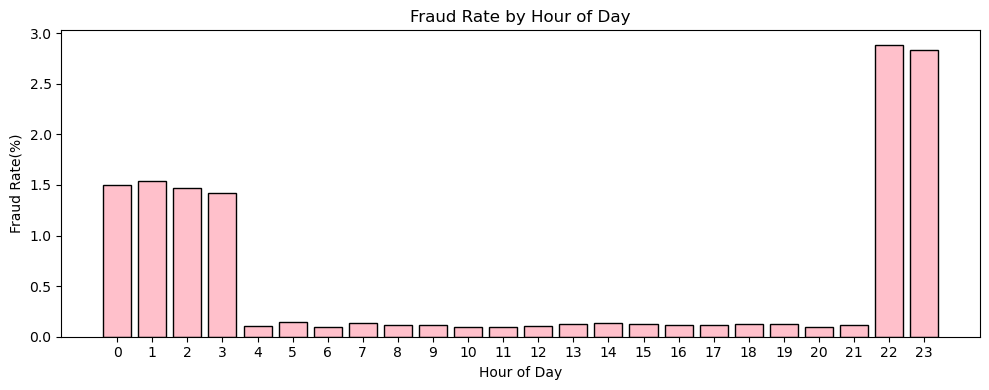

In [25]:
# Fraud rate throughout the day
hourly = df_train_clean.groupby('hour')['is_fraud'].mean() * 100
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly.index, hourly.values, color='pink',edgecolor='black')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Fraud Rate(%)')
ax.set_title('Fraud Rate by Hour of Day')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig('fraud_by_hour.png', dpi=150)
plt.show()

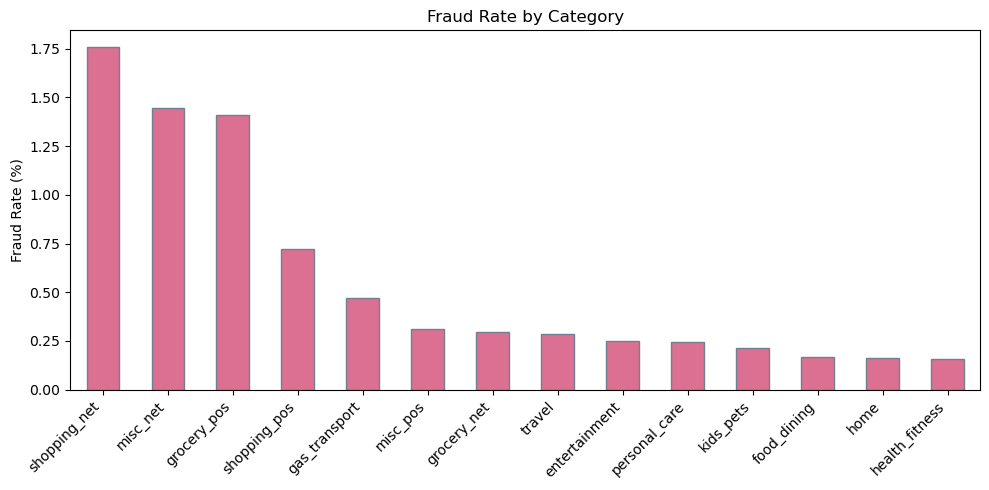

In [61]:
#fraud rate in different areas
cat_fraud = df_train.groupby('category')['is_fraud'].mean().sort_values(ascending=False) * 100
fig, ax = plt.subplots(figsize=(10, 5))
cat_fraud.plot(kind='bar', ax=ax, color='palevioletred',edgecolor='slategrey')
ax.set_title('Fraud Rate by Category')
ax.set_ylabel('Fraud Rate (%)')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('fraud_by_category.png', dpi=150)
plt.show()

## 5. Feature selection according to relevance

In [56]:
# Features selected based on EDA and domain knowledge
FEATURES = ['amt','hour','day_of_week', 'month','age','city_pop','distance_km','gender_enc','category_enc',
            'lat','long','merch_lat', 'merch_long']
TARGET = 'is_fraud'
X_train = df_train_clean[FEATURES]
y_train = df_train_clean[TARGET]
X_test  = df_test_clean[FEATURES]
y_test  = df_test_clean[TARGET]

print('Training features shape:', X_train.shape)
print('Test features shape:', X_test.shape)

Training features shape: (1296675, 13)
Test features shape: (555719, 13)


## 6. Handling Class Imbalance

In [30]:
# this is done so that the imbalance between legitimate and fraud classes is resolved 
#only for a portion because the computer crashes otherwise

from sklearn.model_selection import train_test_split

# Take a 10% stratified sample of training data
X_sample, _, y_sample, _ = train_test_split(X_train, y_train,test_size=0.90,stratify=y_train,random_state=SEED)
print(f'Sample size:{X_sample.shape[0]:,} rows')
print(f'Fraud in sample: {y_sample.sum()} ({y_sample.mean()*100:.2f}%)')

smote = SMOTE(random_state=SEED, k_neighbors=5)
X_resampled, y_resampled = smote.fit_resample(X_sample, y_sample)

print(f'\nAfter solving the imbalance problem: total samples: {len(X_resampled):,}')
print(f'Fraud samples: {y_resampled.sum():,} ({y_resampled.mean()*100:.1f}%)')

Sample size:129,667 rows
Fraud in sample: 751 (0.58%)

After solving the imbalance problem: total samples: 257,832
Fraud samples: 128,916 (50.0%)


## 7. Model Training
Two models are used so that it is comparable and evaluation can be done as to which one is better

1. **Logistic Regression** 
2. **Random Forest** 

In [31]:
#logistic regression
lr = LogisticRegression(max_iter=500, random_state=SEED, class_weight='balanced')
lr.fit(X_resampled, y_resampled)

LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)

In [32]:
# Random forest
rf = RandomForestClassifier(n_estimators=200,max_depth=20,class_weight='balanced',random_state=SEED, n_jobs=-1)
rf.fit(X_resampled, y_resampled)

RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=200,
                       n_jobs=-1, random_state=42)

## 8. Model Evaluation

For fraud detection, **accuracy alone is misleading** due to class imbalance.  
We use:
- **ROC-AUC** that eefctively measures the model's ability to rank fraud above legitimate transactions at all thresholds.
- **Precision-Recall AUC (Average Precision)**: especially informative when the positive class is rare.
- **Confusion Matrix**: shows False Negatives (missed fraud) and False Positives (false alarms).
- **Classification Report**: Precision, Recall, F1 for each class.

In [55]:
lr_probs = lr.predict_proba(X_test)[:, 1]  
rf_probs = rf.predict_proba(X_test)[:, 1]

# Converting probabilities to class predictions using  0.5 threshold
lr_preds = (lr_probs >= 0.5).astype(int)
rf_preds = (rf_probs >= 0.5).astype(int)

# ROC-AUC scores
lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)
print(f'Logistic Regression ROC-AUC: {lr_auc:.4f}')
print(f'Random Forest ROC-AUC: {rf_auc:.4f}')

Logistic Regression ROC-AUC: 0.8544
Random Forest ROC-AUC: 0.9587


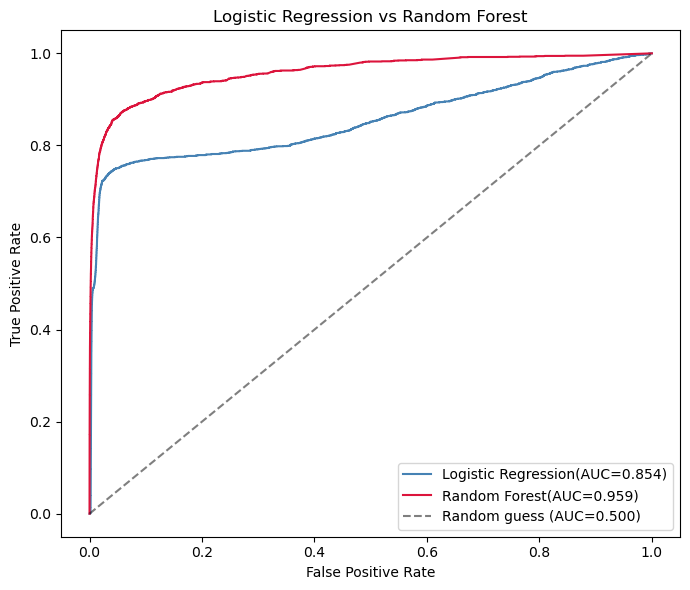

In [53]:
# ROC Curves for comparison of two models
fig, ax = plt.subplots(figsize=(7, 6))

for model_probs, model_name, colour in [(lr_probs,f'Logistic Regression(AUC={lr_auc:.3f})', 'steelblue'),
    (rf_probs,f'Random Forest(AUC={rf_auc:.3f})', 'crimson')]:
    fpr, tpr, _ = roc_curve(y_test, model_probs)
    ax.plot(fpr, tpr, label=model_name, color=colour)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random guess (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Logistic Regression vs Random Forest')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

Random Forest Average Precision (PR-AUC): 0.4604


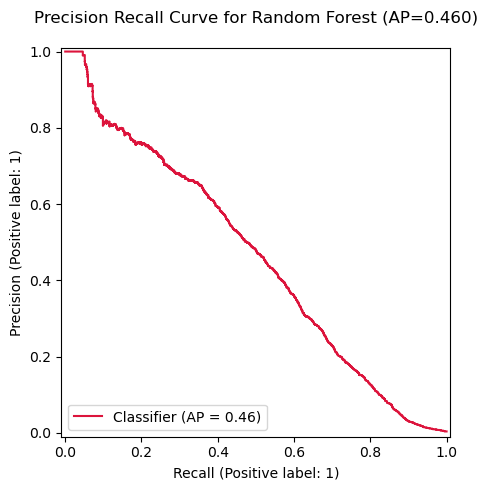

In [50]:
# Presicion recall is used as it better supports class imbalance
avg_precision = average_precision_score(y_test, rf_probs)
print(f'Random Forest Average Precision (PR-AUC): {avg_precision:.4f}')

fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(y_test, rf_probs, ax=ax, color='crimson')
ax.set_title(f'Precision Recall Curve for Random Forest (AP={avg_precision:.3f})\n')
plt.tight_layout()
plt.savefig('precision_recall.png', dpi=150)
plt.show()

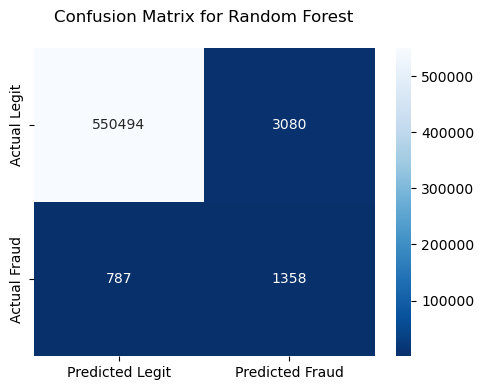

              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00    553574
       Fraud       0.31      0.63      0.41      2145

    accuracy                           0.99    555719
   macro avg       0.65      0.81      0.70    555719
weighted avg       1.00      0.99      0.99    555719



In [48]:
# Confusion matrix for better understanding of the cases
cm = confusion_matrix(y_test, rf_preds)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues_r', ax=ax,xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
ax.set_title('Confusion Matrix for Random Forest\n')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_test, rf_preds, target_names=['Legitimate', 'Fraud']))

## 9. Gini Index to show importance of each feature

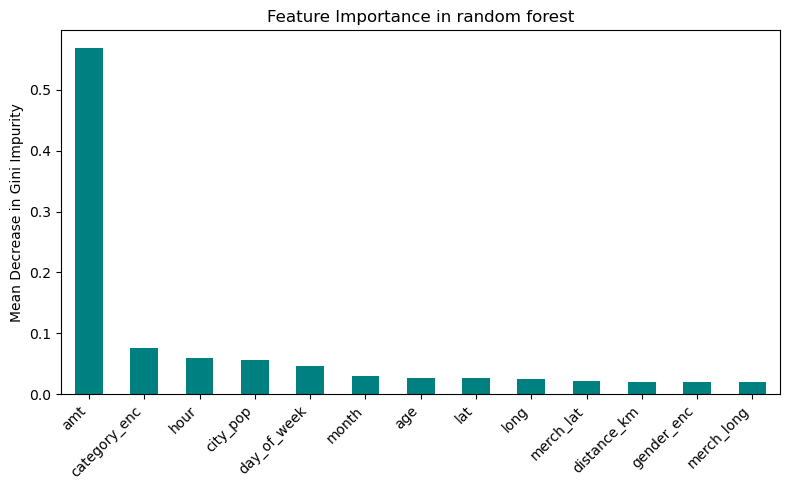

amt             0.568972
category_enc    0.076379
hour            0.059053
city_pop        0.056448
day_of_week     0.046853
month           0.029593
age             0.027248
lat             0.026446
long            0.025303
merch_lat       0.021372
distance_km     0.020878
gender_enc      0.020786
merch_long      0.020668
dtype: float64


In [46]:
# Extracting feature importances
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='bar', color='teal', ax=ax)
ax.set_title('Feature Importance in random forest')
ax.set_ylabel('Mean Decrease in Gini Impurity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print(importances)